In [166]:
from pathlib import Path
import joblib
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import (
    train_test_split, 
    StratifiedKFold, 
    cross_validate, 
    GridSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    classification_report, 
    ConfusionMatrixDisplay
)


pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

In [167]:
dataPath = Path("../data/processed/penn_state_processed_combined_stats.csv")
reportsDir = Path("../reports")
modelsDir = Path("../models")

reportsDir.mkdir(parents=True, exist_ok=True)
modelsDir.mkdir(parents=True, exist_ok=True)

print("Data path:", dataPath.resolve())

Data path: /Users/sirahrahar/Desktop/penn-state-hockey-analytics/data/processed/penn_state_processed_combined_stats.csv


In [168]:
df = pd.read_csv(dataPath)
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (68, 38)


,Date,Opponent,Location,Result,Box Score Link,WMT Game ID,PSU Goals,PSU Shots on Goal,PSU Total Shot Attempts,PSU Faceoffs Won,PSU Faceoffs Lost,PSU Faceoff %,PSU Penalty Minutes,PSU Blocks,PSU Saves,Opponent Goals,Opponent Shots on Goal,Opponent Total Shot Attempts,Opponent Faceoffs Won,Opponent Faceoffs Lost,Opponent Faceoff %,Opponent Penalty Minutes,Opponent Blocks,Opponent Saves,Win,Goal Differential,Shot Differential,Total Shots on Goal,Faceoff Differential,PSU Save %,Opponent Save %,Home Game,Venue_Type,Total Goals,Total Penalty Minutes,PSU Shooting %,Opponent Shooting %,Season
0,Friday Oct 3,Arizona State,"Tempe, Ariz. / Mullett Arena",W Win 6-3,https://gopsusports.com/boxscore/17959,6440318,6,47,69,32,45,41.56,18,16,35,3,38,65,45,32,58.44,16,13,41,1,3,9,85,-16.88,0.921,0.872,0,Away,9,34,12.765957,7.894737,2025-2026
1,Saturday Oct 4,Arizona State,"Tempe, Ariz. / Mullett Arena",W Win 4-2,https://gopsusports.com/boxscore/17960,6440319,4,46,76,29,42,40.85,14,13,45,2,47,69,42,29,59.15,8,17,42,1,2,-1,93,-18.30,0.957,0.913,0,Away,6,22,8.695652,4.255319,2025-2026
2,Thursday Oct 9,Clarkson,"University Park, Pa. / Pegula Ice Arena",L Loss 4-6,https://gopsusports.com/boxscore/17961,6440320,4,40,75,37,30,55.22,14,12,20,6,26,45,30,37,44.78,14,21,36,0,-2,14,66,10.44,0.769,0.900,1,Home,10,28,10.000000,23.076923,2025-2026
3,Friday Oct 10,Clarkson,"University Park, Pa. / Pegula Ice Arena",W Win 5-2,https://gopsusports.com/boxscore/17962,6440321,5,31,57,30,24,55.56,75,11,21,2,23,39,24,30,44.44,77,13,26,1,3,8,54,11.12,0.913,0.839,1,Home,7,152,16.129032,8.695652,2025-2026
4,Friday Oct 17,LIU,"University Park, Pa. / Pegula Ice Arena",W Win 5-4,https://gopsusports.com/boxscore/17963,6424375,5,41,66,37,33,52.86,10,15,32,4,36,63,33,37,47.14,25,11,36,1,1,5,77,5.72,0.889,0.878,1,Home,9,35,12.195122,11.111111,2025-2026


In [169]:
features = [
    "PSU Shots on Goal",
    "Opponent Shots on Goal",
    "Shot Differential",
    "PSU Faceoff %",
    "Opponent Faceoff %",
    "Faceoff Differential",
    "PSU Blocks", 
    "Opponent Blocks",
    "PSU Penalty Minutes", 
    "Opponent Penalty Minutes"
]

target = "Win"

missingColumns = [column for column in features+[target] if column not in df.columns]

if missingColumns:
    raise ValueError(f"Missing required columns: {missingColumns}")

In [170]:
modeldf = df[features+[target]].copy()
modeldf = modeldf.dropna().reset_index(drop=True)
X = modeldf[features]
y = modeldf[target].astype(int)
print("Modeling row:", len(modeldf))
print("\nClass counts:")
print(y.value_counts().sort_index())
print("\nFeatures:")
print(features)

Modeling row: 68

Class counts:
Win
0    28
1    40
Name: count, dtype: int64

Features:
['PSU Shots on Goal', 'Opponent Shots on Goal', 'Shot Differential', 'PSU Faceoff %', 'Opponent Faceoff %', 'Faceoff Differential', 'PSU Blocks', 'Opponent Blocks', 'PSU Penalty Minutes', 'Opponent Penalty Minutes']


In [171]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20, random_state=42, stratify=y)
print("training games:", len(X_train))
print("testing games:", len(X_test))

training games: 54
testing games: 14


In [172]:
models = {
    "Logistic Regression":Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=1000, random_state=42))
        ]
    ),
    "Decision Tree":DecisionTreeClassifier(max_depth=4, random_state=42),
    "Random Forest":RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42), 
    "Gradient Boosting":GradientBoostingClassifier(random_state=42)
}

In [173]:
holdoutResults = []
trainedModels = {}

for modelName, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    trainedModels[modelName] = model

    holdoutResults.append(
        {
            "Model":modelName,
            "Accuracy":accuracy_score(y_test, predictions),
            "Precision":precision_score(y_test, predictions, zero_division=0),
            "Recall":recall_score(y_test, predictions, zero_division=0),
            "F1 Score":f1_score(y_test, predictions, zero_division=0)
        }
    )
holdoutResults_df = pd.DataFrame(holdoutResults)
holdoutResults_df = holdoutResults_df.sort_values("F1 Score", ascending=False).reset_index(drop=True)
holdoutResults_df


,Model,Accuracy,Precision,Recall,F1 Score
0,Gradient Boosting,1.000000,1.000000,1.000,1.000000
1,Random Forest,0.857143,0.800000,1.000,0.888889
2,Decision Tree,0.714286,0.700000,0.875,0.777778
3,Logistic Regression,0.571429,0.583333,0.875,0.700000


In [174]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    "accuracy":"accuracy",
    "precision":"precision",
    "recall":"recall",
    "f1":"f1"
}

In [175]:
cv_results = []

for modelName, model in models.items():
    scores=cross_validate(
        estimator=model, 
        X=X,
        y=y,
        cv=skf,
        scoring=scoring,
        return_train_score=False
    )

    cv_results.append(
        {
            "Model":modelName,
            "Mean Accuracy":scores["test_accuracy"].mean(),
            "Accuracy Std":scores["test_accuracy"].std(),
            "Mean Precision":scores["test_precision"].mean(),
            "Mean Recall":scores["test_recall"].mean(),
            "Mean F1 Score":scores["test_f1"].mean(),
            "F1 Std":scores["test_f1"].std()
        }
    )

cv_results_df = pd.DataFrame(cv_results)
cv_results_df = cv_results_df.sort_values("Mean F1 Score", ascending=False).reset_index(drop=True)
cv_results_df

,Model,Mean Accuracy,Accuracy Std,Mean Precision,Mean Recall,Mean F1 Score,F1 Std
0,Random Forest,0.984615,0.030769,0.977778,1.000,0.988235,0.023529
1,Gradient Boosting,0.969231,0.061538,1.000000,0.950,0.971429,0.057143
2,Decision Tree,0.927473,0.063925,0.897778,1.000,0.943791,0.049708
3,Logistic Regression,0.719780,0.034401,0.755556,0.775,0.764706,0.029412


In [176]:
holdoutResults_df.to_csv(reportsDir/"model_holdout_results.csv", index=False)
cv_results_df.to_csv(reportsDir/"cross_validation_results.csv", index=False)
print("Saved:")
print(reportsDir/"model_holdout_results.csv")
print(reportsDir/"cross_validation_results.csv")

Saved:
../reports/model_holdout_results.csv
../reports/cross_validation_results.csv


In [177]:
rf_param_grid = {
    "n_estimators":[100,200,300],
    "max_depth":[3,5,7,None],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4]
}

In [178]:
rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_param_grid,
    cv=skf,
    scoring="f1",
    n_jobs=-1,
    refit=True
)

rf_grid.fit(X_train, y_train)

print("Best parameters:")
print(rf_grid.best_params_)

print("\nBest Training-CV F1:")
print(round(rf_grid.best_score_, 4))

Best parameters:
{'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Best Training-CV F1:
0.9251


In [179]:
tuned_rf=rf_grid.best_estimator_

tuned_predictions = tuned_rf.predict(X_test)

tuned_rf_results = pd.DataFrame(
    [{
        "Model": "Tuned Random Forest", 
        "Accuracy":accuracy_score(y_test, tuned_predictions),
        "Precision":precision_score(y_test, tuned_predictions, zero_division=0),
        "Recall":recall_score(y_test, tuned_predictions, zero_division=0),
        "F1 Score":f1_score(y_test, tuned_predictions, zero_division=0)
    }]
)

tuned_rf_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Tuned Random Forest,0.857143,0.8,1.0,0.888889


In [180]:
print(classification_report(y_test, tuned_predictions, zero_division=0))

              precision    recall  f1-score   support

           0       1.00      0.67      0.80         6
           1       0.80      1.00      0.89         8

    accuracy                           0.86        14
   macro avg       0.90      0.83      0.84        14
weighted avg       0.89      0.86      0.85        14



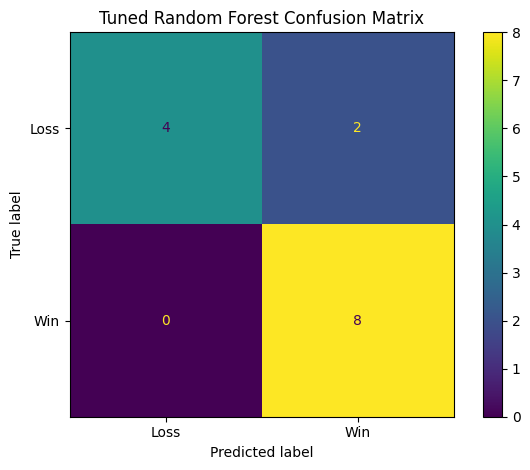

In [181]:
ConfusionMatrixDisplay.from_predictions(y_test, tuned_predictions, display_labels=["Loss", "Win"])

plt.title("Tuned Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

In [182]:
feature_importance_df=pd.DataFrame({
    "Feature":features, 
    "Importance":(tuned_rf.feature_importances_)
})

feature_importance_df = feature_importance_df.sort_values("Importance", ascending=False).reset_index(drop=True)
feature_importance_df

,Feature,Importance
0,Shot Differential,0.193555
1,PSU Blocks,0.170681
2,PSU Shots on Goal,0.144402
3,PSU Faceoff %,0.091801
4,PSU Penalty Minutes,0.079442
5,Faceoff Differential,0.078973
6,Opponent Faceoff %,0.077191
7,Opponent Blocks,0.066310
8,Opponent Penalty Minutes,0.052470
9,Opponent Shots on Goal,0.045175


In [183]:
feature_importance_df.to_csv(reportsDir/"tuned_random_forest_feature_importance.csv", index=False)
print("saved!")

saved!


In [184]:
joblib.dump(tuned_rf,modelsDir /"tuned_random_forest.joblib",)

joblib.dump(features, modelsDir /"model_features.joblib",)

print("Saved:")
print(modelsDir /"tuned_random_forest.joblib")

print(modelsDir /"model_features.joblib")

Saved:
../models/tuned_random_forest.joblib
../models/model_features.joblib


In [185]:
best_cv_row = cv_results_df.iloc[0]

best_holdout_row = holdoutResults_df.iloc[0]

print(
    "Best baseline model by "
    "cross-validation F1:"
)

print(
    best_cv_row[
        [
            "Model",
            "Mean F1 Score",
            "F1 Std",
        ]
    ]
)

print(
    "\nBest baseline model "
    "on the holdout set:"
)

print(
    best_holdout_row[
        [
            "Model",
            "F1 Score",
        ]
    ]
)

print(
    "\nTuned Random Forest "
    "holdout F1:"
)

print(
    round(
        tuned_rf_results.loc[
            0,
            "F1 Score",
        ],
        4,
    )
)

Best baseline model by cross-validation F1:
Model            Random Forest
Mean F1 Score         0.988235
F1 Std                0.023529
Name: 0, dtype: object

Best baseline model on the holdout set:
Model       Gradient Boosting
F1 Score                  1.0
Name: 0, dtype: object

Tuned Random Forest holdout F1:
0.8889
